In [1]:
# ==============================================================================
# CELL 1: SETUP AND ENVIRONMENT CONFIGURATION (DEEPSHIP)
# ==============================================================================

# 1. Mount Google Drive to access the dataset (MUST BE EXECUTED)
from google.colab import drive
drive.mount('/content/drive')

# 2. Install required libraries
print("Installing required packages...")
!pip install librosa soundfile pandas tqdm scikit-learn -q

# 3. Import necessary libraries
import numpy as np
import pandas as pd
import librosa
import os
import glob
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import warnings
import pickle
warnings.filterwarnings('ignore') # Ignore librosa warnings

# 4. Define Paths (ADJUST THESE TO YOUR SPECIFIC DRIVE LOCATION)
# -----------------------------------------------------------------------------
# Path to the root folder containing your DeepShip dataset
# (This folder should contain subdirectories: 'Cargo', 'Passengership', 'Tanker', 'Tug')
DATASET_ROOT_PATH = '/content/drive/MyDrive/DeepShip-main'

# Directory to save all processed data files (will be created if it doesn't exist)
SAVE_DIR = '/content/drive/MyDrive/processed_data_DeepShip_DWSTr'
# -----------------------------------------------------------------------------

print("\nEnvironment setup complete. Paths configured:")
print(f"  Dataset Root: {DATASET_ROOT_PATH}")
print(f"  Save Directory: {SAVE_DIR}")
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive
Installing required packages...

Environment setup complete. Paths configured:
  Dataset Root: /content/drive/MyDrive/DeepShip-main
  Save Directory: /content/drive/MyDrive/processed_data_DeepShip_DWSTr


In [2]:
# ==============================================================================
# CELL 2: DWSTR PREPROCESSOR CLASS
# ==============================================================================

class DWSTrPreprocessor:
    """
    Implements the DWSTr paper's preprocessing steps:
    - 75ms segmenting (1654 samples @ 22050 Hz)
    - Pre-emphasis filter
    - 128x4 Mel-spectrogram extraction (n_fft=2048, hop_length=512)
    """

    def __init__(self):
        self.sr = 22050
        self.segment_duration = 0.075
        self.segment_samples = int(self.sr * self.segment_duration)
        self.n_fft = 2048
        self.hop_length = 512
        self.n_mels = 128
        self.fmax = self.sr // 2
        print(f"DWSTr Preprocessor initialized. Output shape: ({self.n_mels}x4)")

    def preemphasis(self, audio: np.ndarray, coef: float = 0.97) -> np.ndarray:
        """Apply pre-emphasis filter: y[n] = x[n] - 0.97*x[n-1]"""
        return np.append(audio[0], audio[1:] - coef * audio[:-1])

    def segment_audio(self, audio: np.ndarray) -> list[np.ndarray]:
        """Segment audio into 75ms non-overlapping clips."""
        segments = []
        for start in range(0, len(audio) - self.segment_samples + 1, self.segment_samples):
            segment = audio[start:start + self.segment_samples]
            if len(segment) == self.segment_samples:
                segments.append(segment)
        return segments

    def extract_mel_spectrogram(self, segment: np.ndarray) -> np.ndarray:
        """Extract 128x4 Mel-spectrogram and convert to dB."""

        emphasized = self.preemphasis(segment)

        mel_spec = librosa.feature.melspectrogram(
            y=emphasized,
            sr=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            power=2.0,  # Power spectrum
            window='hann'
        )

        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Ensure 128x4 shape (padding/trimming for robustness)
        expected_frames = 4
        if mel_spec_db.shape[1] != expected_frames:
            if mel_spec_db.shape[1] < expected_frames:
                pad_width = expected_frames - mel_spec_db.shape[1]
                mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='edge')
            else:
                mel_spec_db = mel_spec_db[:, :expected_frames]

        return mel_spec_db

    def process_file(self, audio_path: str) -> np.ndarray:
        """Complete processing pipeline for one audio file."""
        # Load audio at the required sampling rate
        audio, _ = librosa.load(audio_path, sr=self.sr, mono=True)

        segments = self.segment_audio(audio)

        mel_specs = []
        for segment in segments:
            mel_spec = self.extract_mel_spectrogram(segment)
            mel_specs.append(mel_spec)

        return np.array(mel_specs)

In [3]:
# ==============================================================================
# CELL 3: DIRECTORY-BASED DATA LOADING FOR DEEPSHIP
# ==============================================================================

def get_deepship_classes(dataset_path: str) -> tuple:
    """
    Dynamically extracts class names from the subdirectory structure.
    DeepShip is organized as: dataset_root/Class_Name/ship_name/audio.wav
    """
    # Find immediate subdirectories in the dataset root
    class_names = sorted([d for d in os.listdir(dataset_path)
                          if os.path.isdir(os.path.join(dataset_path, d))])

    class_to_idx = {name: i for i, name in enumerate(class_names)}

    print(f"DeepShip classes mapped. Found {len(class_names)} unique classes: {class_names}")
    return class_names, class_to_idx

def load_and_process_deepship_data(dataset_path: str) -> tuple:
    """
    Loads audio, processes it into Mel-spectrograms, and assigns labels
    using the parent directory name as the class label.
    """
    class_names, class_to_idx = get_deepship_classes(dataset_path)

    preprocessor = DWSTrPreprocessor()
    X_list = []
    y_list = []

    # Search for all WAV files recursively
    audio_files = glob.glob(os.path.join(dataset_path, '**', '*.wav'), recursive=True)

    print(f"\nFound {len(audio_files)} total audio files to process.")
    print("This step can be slow and memory-intensive. Please use a high-RAM Colab runtime.")

    for audio_file in tqdm(audio_files, desc="Preprocessing DeepShip Audio"):
        try:
            # Extract class name from the parent folder
            # E.g., .../DeepShip/Cargo/ship_1/audio.wav -> we need 'Cargo'
            # We move two directories up from the file to get the class name
            # Or simpler: parse the path parts.
            path_parts = os.path.normpath(audio_file).split(os.sep)

            # Find which class name is in the path
            class_name = None
            for cls in class_names:
                if cls in path_parts:
                    class_name = cls
                    break

            if class_name in class_to_idx:
                class_idx = class_to_idx[class_name]

                # Process file to get Mel-spectrograms (multiple 75ms segments)
                mel_specs = preprocessor.process_file(audio_file)

                if len(mel_specs) > 0:
                    X_list.extend(mel_specs)
                    y_list.extend([class_idx] * len(mel_specs))

        except Exception as e:
            # Skip corrupted or unreadable files gracefully
            continue

    # Convert to NumPy arrays and add channel dimension
    X = np.expand_dims(np.array(X_list), axis=-1)
    y = np.array(y_list)

    print("\n" + "="*60)
    print(f"Preprocessing Complete: {len(X)} total segments generated.")
    print(f"Initial Feature Shape: {X.shape}")
    print("="*60)

    # ⚠️ CRITICAL: Clear memory after conversion
    del X_list, y_list

    return X, y, class_names

In [6]:
# ==============================================================================
# CELL 4: KAGGLE API DOWNLOAD AND PREPROCESSING (ALL-IN-ONE)
# ==============================================================================
import os
import zipfile
import numpy as np
import pickle

# 1. Setup Kaggle API securely
print("Setting up Kaggle API...")
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2. Download the DeepShip dataset directly from Kaggle
print("\nDownloading DeepShip dataset...")
!kaggle datasets download -d vasundharauppuluri/deep-ship -p /content

# 3. Unzip the dataset
ZIP_PATH = '/content/deep-ship.zip'
EXTRACT_DIR = '/content/DeepShip_Dataset'

if os.path.exists(ZIP_PATH):
    print(f"\nExtracting {ZIP_PATH} to {EXTRACT_DIR}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete!")
else:
    raise FileNotFoundError("Dataset zip file not found! Check if kaggle.json is uploaded.")

# 4. Determine correct path (handling the Kaggle 'DeepShip-main' nested folder)
if os.path.exists(os.path.join(EXTRACT_DIR, 'DeepShip-main')):
    DATASET_ROOT_PATH = os.path.join(EXTRACT_DIR, 'DeepShip-main')
elif os.path.exists(os.path.join(EXTRACT_DIR, 'DeepShip')):
    DATASET_ROOT_PATH = os.path.join(EXTRACT_DIR, 'DeepShip')
else:
    DATASET_ROOT_PATH = EXTRACT_DIR

# 5. Execute the loading and processing pipeline
print(f"\nTargeting dataset root: {DATASET_ROOT_PATH}")
print("Starting DeepShip processing pipeline...")
X_all, y_all, class_names = load_and_process_deepship_data(DATASET_ROOT_PATH)

# 6. Save the full dataset immediately to your Google Drive
temp_save_path = os.path.join(SAVE_DIR, 'full_data_preprocessed.npz')
print(f"Saving full dataset to {temp_save_path}...")
np.savez_compressed(temp_save_path, X=X_all, y=y_all)
print("Save complete. Data is secure on Drive.")

# 7. Explicitly delete the variables to free up RAM
del X_all, y_all
print("Memory cleared for X_all and y_all.")

# 8. Save class names for later reference
class_names_path = os.path.join(SAVE_DIR, 'class_names.pkl')
with open(class_names_path, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Class names saved to {class_names_path}")

Setting up Kaggle API...
cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory

Dataset URL: https://www.kaggle.com/datasets/vasundharauppuluri/deep-ship
License(s): MIT
100% 503M/503M [00:28<00:00, 18.3MB/s]


Extracting /content/deep-ship.zip to /content/DeepShip_Dataset...
Extraction complete!

Targeting dataset root: /content/DeepShip_Dataset/DeepShip-main
Starting DeepShip processing pipeline...
DeepShip classes mapped. Found 4 unique classes: ['Cargo', 'Passengership', 'Tanker', 'Tug']
DWSTr Preprocessor initialized. Output shape: (128x4)

Found 63 total audio files to process.
This step can be slow and memory-intensive. Please use a high-RAM Colab runtime.


Preprocessing DeepShip Audio:   0%|          | 0/63 [00:00<?, ?it/s]


Preprocessing Complete: 76311 total segments generated.
Initial Feature Shape: (76311, 128, 4, 1)
Saving full dataset to /content/drive/MyDrive/processed_data_DeepShip_DWSTr/full_data_preprocessed.npz...
Save complete. Data is secure on Drive.
Memory cleared for X_all and y_all.
Class names saved to /content/drive/MyDrive/processed_data_DeepShip_DWSTr/class_names.pkl


Generating research-grade matrix for 4 classes...


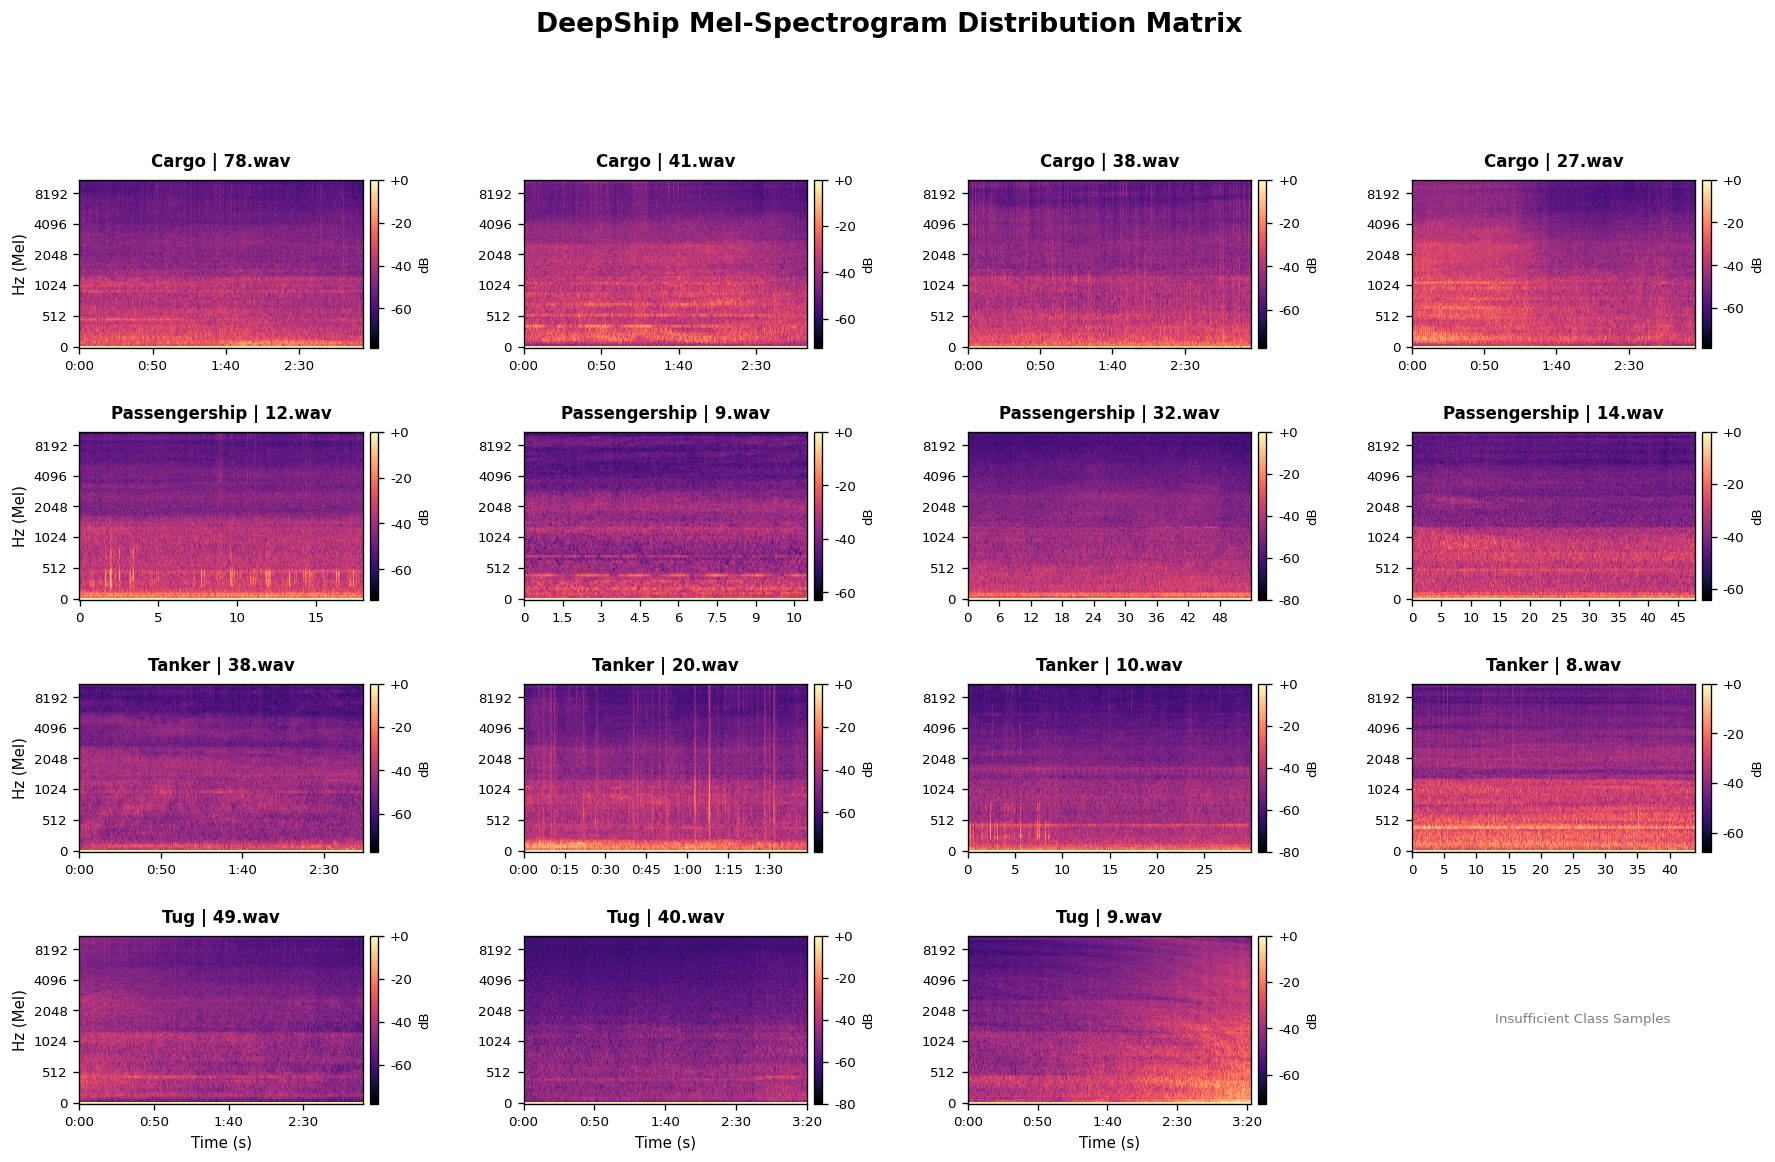

In [7]:
# ==============================================================================
# CELL 4.5: PROFESSIONAL MEL-SPECTROGRAM MATRIX VISUALIZATION
# ==============================================================================
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import glob

SAMPLES_PER_CLASS = 4

# 1. Map classes dynamically
class_names = sorted([d for d in os.listdir(DATASET_ROOT_PATH)
                      if os.path.isdir(os.path.join(DATASET_ROOT_PATH, d))])
num_classes = len(class_names)

print(f"Generating research-grade matrix for {num_classes} classes...")

# 2. Setup Figure (Strict Row=Class alignment)
fig, axes = plt.subplots(
    nrows=num_classes,
    ncols=SAMPLES_PER_CLASS,
    figsize=(4 * SAMPLES_PER_CLASS + 2, 2.5 * num_classes),
    dpi=120,
    squeeze=False
)
fig.subplots_adjust(hspace=0.5, wspace=0.3)

# 3. Populate Grid
for row_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_ROOT_PATH, class_name)
    audio_files = glob.glob(os.path.join(class_dir, '**', '*.wav'), recursive=True)

    # Sample files, gracefully accommodating classes with fewer than SAMPLES_PER_CLASS
    sampled_files = random.sample(audio_files, min(SAMPLES_PER_CLASS, len(audio_files)))

    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx, col_idx]

        if col_idx < len(sampled_files):
            audio_path = sampled_files[col_idx]
            # Truncate long filenames to keep the layout clean
            file_name = os.path.basename(audio_path)
            display_name = file_name if len(file_name) < 20 else file_name[:17] + '...'

            # Load & Compute (using exact DWSTr paper parameters)
            y, sr = librosa.load(audio_path, sr=22050, mono=True)
            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128,
                power=2.0, window='hann', fmax=sr//2
            )
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            # Plot the spectrogram
            img = librosa.display.specshow(
                mel_spec_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel',
                fmax=sr//2, cmap='magma', ax=ax
            )

            # Add compact, readable colorbar
            cbar = fig.colorbar(img, ax=ax, format='%+2.0f', pad=0.02)
            cbar.ax.tick_params(labelsize=8)
            cbar.set_label('dB', size=8)

            # Title & Data-Ink Axis cleanup
            ax.set_title(f"{class_name} | {display_name}", fontsize=10, fontweight='bold', pad=8)
            ax.tick_params(axis='both', which='major', labelsize=8)

            # Only label the outer edges of the matrix
            ax.set_xlabel('Time (s)', fontsize=9) if row_idx == num_classes - 1 else ax.set_xlabel('')
            ax.set_ylabel('Hz (Mel)', fontsize=9) if col_idx == 0 else ax.set_ylabel('')

        else:
            # Handle missing data elegantly (e.g., Tug class missing its 4th file)
            ax.axis('off')
            # Add a subtle marker indicating why the space is blank
            ax.text(0.5, 0.5, 'Insufficient Class Samples',
                    horizontalalignment='center', verticalalignment='center',
                    fontsize=8, color='gray', transform=ax.transAxes)

plt.suptitle("DeepShip Mel-Spectrogram Distribution Matrix", fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [8]:
# ==============================================================================
# CELL 5: DATA SPLITTING AND FINAL SAVE
# ==============================================================================

# 1. Reload the data from the compressed file (low memory cost)
print("Reloading full data for splitting...")
temp_save_path = os.path.join(SAVE_DIR, 'full_data_preprocessed.npz')
data = np.load(temp_save_path)
X = data['X']
y = data['y']
total_samples = len(X)

print(f"Data reloaded. Total samples: {total_samples}")
print(f"Data shape: {X.shape}")

# 2. Define the Split Ratios
TRAIN_RATIO = 0.7
TEST_RATIO = 0.2
VAL_RATIO = 0.1
RANDOM_STATE = 42

# 3. First split: Train vs (Test + Val)
print("\nPerforming stratified splitting (70% Train, 20% Test, 10% Val)...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(TEST_RATIO + VAL_RATIO),
    stratify=y,
    random_state=RANDOM_STATE
)

# 4. Second split: Test vs Val
val_ratio_adjusted = VAL_RATIO / (TEST_RATIO + VAL_RATIO)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio_adjusted,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# 5. Final Save
print("Splitting complete. Saving final array files to Drive...")
np.savez_compressed(os.path.join(SAVE_DIR, 'train_data.npz'), X=X_train, y=y_train)
np.savez_compressed(os.path.join(SAVE_DIR, 'test_data.npz'), X=X_test, y=y_test)
np.savez_compressed(os.path.join(SAVE_DIR, 'val_data.npz'), X=X_val, y=y_val)

# 6. Summary and Cleanup
print("\n" + "="*60)
print("DATASET SPLIT SUMMARY")
print("="*60)
print(f"Training samples:   {len(X_train):,} ({len(X_train)/total_samples:.1%})")
print(f"Testing samples:    {len(X_test):,} ({len(X_test)/total_samples:.1%})")
print(f"Validation samples: {len(X_val):,} ({len(X_val)/total_samples:.1%})")
print(f"\nFinal files successfully saved to: {SAVE_DIR}")

# Free up RAM
del X, y, X_temp, y_temp
print("Memory cleared.")

Reloading full data for splitting...
Data reloaded. Total samples: 76311
Data shape: (76311, 128, 4, 1)

Performing stratified splitting (70% Train, 20% Test, 10% Val)...
Splitting complete. Saving final array files to Drive...

DATASET SPLIT SUMMARY
Training samples:   53,417 (70.0%)
Testing samples:    15,262 (20.0%)
Validation samples: 7,632 (10.0%)

Final files successfully saved to: /content/drive/MyDrive/processed_data_DeepShip_DWSTr
Memory cleared.


In [9]:
# ==============================================================================
# CELL 6: LOAD FINAL DATA AND SANITY CHECK
# ==============================================================================
import os
import numpy as np
import pickle

def load_final_data(data_dir: str):
    """Loads the final processed data splits from Drive. (More efficient)"""

    # Load arrays (More efficient: load file once, then access keys)
    with np.load(os.path.join(data_dir, 'train_data.npz')) as data:
        X_train, y_train = data['X'], data['y']

    with np.load(os.path.join(data_dir, 'test_data.npz')) as data:
        X_test, y_test = data['X'], data['y']

    with np.load(os.path.join(data_dir, 'val_data.npz')) as data:
        X_val, y_val = data['X'], data['y']

    # Load class names
    with open(os.path.join(data_dir, 'class_names.pkl'), 'rb') as f:
        class_names = pickle.load(f)

    print("\n" + "="*60)
    print("Final Data Loaded for Model Training")
    print("="*60)
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"Number of Classes: {len(class_names)} ({class_names})")

    return X_train, X_test, X_val, y_train, y_test, y_val, class_names

# Execute the final load
X_train, X_test, X_val, y_train, y_test, y_val, class_names = load_final_data(SAVE_DIR)

# Sanity Check: Ensure required shape
print("\nRunning quick integrity check:")
print(f"  Expected feature shape (128, 4, 1): {X_train.shape[1:] == (128, 4, 1)}")
print(f"  Train label count: {len(y_train)} | Test label count: {len(y_test)}")


Final Data Loaded for Model Training
X_train shape: (53417, 128, 4, 1)
X_test shape: (15262, 128, 4, 1)
X_val shape: (7632, 128, 4, 1)
Number of Classes: 4 (['Cargo', 'Passengership', 'Tanker', 'Tug'])

Running quick integrity check:
  Expected feature shape (128, 4, 1): True
  Train label count: 53417 | Test label count: 15262


In [10]:
# ==============================================================================
# CELL 7: IMPORT TENSORFLOW/KERAS AND SET RANDOM SEEDS
# ==============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Configure GPU memory growth (prevents OOM errors)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU memory growth enabled


In [11]:
# ==============================================================================
# CELL 8: DEPTHWISE SEPARABLE CONVOLUTION (DWS) BLOCK
# ==============================================================================

def create_dws_block(input_shape=(128, 4, 1), num_filters=64):
    inputs = layers.Input(shape=input_shape, name='mel_spectrogram_input')

    # Depthwise Convolution Layer
    x = layers.DepthwiseConv2D(
        kernel_size=(3, 3), strides=(1, 1), padding='same',
        dilation_rate=(1, 1), depthwise_initializer='glorot_uniform', name='depthwise_conv'
    )(inputs)
    x = layers.BatchNormalization(name='dw_batch_norm')(x)
    x = layers.ReLU(name='dw_relu')(x)

    # Pointwise Convolution Layer
    x = layers.Conv2D(
        filters=num_filters, kernel_size=(1, 1), strides=(1, 1),
        padding='valid', kernel_initializer='glorot_uniform', name='pointwise_conv'
    )(x)
    x = layers.BatchNormalization(name='pw_batch_norm')(x)
    x = layers.ReLU(name='pw_relu')(x)

    model = models.Model(inputs=inputs, outputs=x, name='DWS_Block')
    return model

In [12]:
# ==============================================================================
# CELL 9: TRANSFORMER ENCODER BLOCK
# ==============================================================================

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout_rate

        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=dropout_rate, name="multi_head_attention")
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout_rate),
            layers.Dense(embed_dim),
            layers.Dropout(dropout_rate),
        ], name="mlp_block")

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6, name="layernorm_1")
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6, name="layernorm_2")

    def call(self, inputs, training=False):
        inputs_norm = self.layernorm1(inputs)
        attn_output = self.att(query=inputs_norm, value=inputs_norm, key=inputs_norm, training=training)
        x = inputs + attn_output
        x_norm = self.layernorm2(x)
        mlp_output = self.mlp(x_norm, training=training)
        return x + mlp_output

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim, "num_heads": self.num_heads,
            "mlp_dim": self.mlp_dim, "dropout_rate": self.dropout_rate,
        })
        return config

In [13]:
# ==============================================================================
# CELL 10: COMPLETE DWSTr ARCHITECTURE
# ==============================================================================

class ClassTokenLayer(layers.Layer):
    def __init__(self, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim
    def build(self, input_shape):
        self.class_token = self.add_weight(name='class_token', shape=(1, 1, self.projection_dim), initializer='random_normal', trainable=True)
        super().build(input_shape)
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        class_tokens = tf.broadcast_to(self.class_token, [batch_size, 1, self.projection_dim])
        return tf.concat([class_tokens, inputs], axis=1)
    def get_config(self):
        config = super().get_config()
        config.update({"projection_dim": self.projection_dim})
        return config

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_positions, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_positions = num_positions
        self.projection_dim = projection_dim
        self.position_embedding = layers.Embedding(input_dim=num_positions, output_dim=projection_dim)
    def call(self, inputs):
        positions = tf.range(start=0, limit=self.num_positions, delta=1)
        position_embeddings = self.position_embedding(positions)
        return inputs + position_embeddings
    def get_config(self):
        config = super().get_config()
        config.update({"num_positions": self.num_positions, "projection_dim": self.projection_dim})
        return config

def create_dwstr_model(
    input_shape=(128, 4, 1), num_classes=4, dws_filters=64, patch_size=4,
    projection_dim=64, num_transformer_blocks=6, num_heads=4, mlp_dim=1024, dropout_rate=0.3
):
    inputs = layers.Input(shape=input_shape, name='input')

    # DWS Block
    dws_block = create_dws_block(input_shape=input_shape, num_filters=dws_filters)
    feature_map = dws_block(inputs)

    # Patch Embedding
    num_patches_h = input_shape[0] // patch_size
    num_patches_w = input_shape[1] // patch_size
    num_patches = num_patches_h * num_patches_w

    patches = layers.Reshape((num_patches, (patch_size * patch_size * dws_filters)))(feature_map)
    patch_embeddings = layers.Dense(projection_dim, name='patch_projection')(patches)

    # Class Token and Positional Embedding
    patch_embeddings = ClassTokenLayer(projection_dim)(patch_embeddings)
    num_positions = num_patches + 1
    encoded_patches = PositionalEmbedding(num_positions, projection_dim)(patch_embeddings)
    encoded_patches = layers.Dropout(dropout_rate)(encoded_patches)

    # Transformer Encoders
    for i in range(num_transformer_blocks):
        encoded_patches = TransformerBlock(
            embed_dim=projection_dim, num_heads=num_heads, mlp_dim=mlp_dim,
            dropout_rate=dropout_rate, name=f'transformer_block_{i}'
        )(encoded_patches)

    # Classification Head
    representation = layers.Lambda(lambda x: x[:, 0], name='extract_class_token')(encoded_patches)
    representation = layers.LayerNormalization(epsilon=1e-6)(representation)
    representation = layers.Dropout(dropout_rate)(representation)
    representation = layers.Dense(mlp_dim, activation='gelu')(representation)
    representation = layers.Dropout(dropout_rate)(representation)

    outputs = layers.Dense(num_classes, activation='softmax', name='classification_output')(representation)
    model = models.Model(inputs=inputs, outputs=outputs, name='DWSTr')

    return model

In [14]:
# ==============================================================================
# CELL 11: BUILD AND COMPILE MODEL
# ==============================================================================

# Model hyperparameters
MODEL_CONFIG = {
    'input_shape': (128, 4, 1),
    'num_classes': len(class_names), # Dynamically captures the 4 DeepShip classes
    'dws_filters': 64,
    'patch_size': 4,
    'projection_dim': 64,
    'num_transformer_blocks': 6,
    'num_heads': 4,
    'mlp_dim': 1024,
    'dropout_rate': 0.3
}

print("Building DWSTr model with configuration:")
for key, value in MODEL_CONFIG.items():
    print(f"  {key}: {value}")

# Create model
model = create_dwstr_model(**MODEL_CONFIG)

# Compile model with Adam optimizer
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\n" + "="*60)
print("MODEL ARCHITECTURE SUMMARY")
print("="*60)
model.summary()

# Calculate total parameters
total_params = model.count_params()
print(f"\n📊 Total Parameters: {total_params:,}")

Building DWSTr model with configuration:
  input_shape: (128, 4, 1)
  num_classes: 4
  dws_filters: 64
  patch_size: 4
  projection_dim: 64
  num_transformer_blocks: 6
  num_heads: 4
  mlp_dim: 1024
  dropout_rate: 0.3

MODEL ARCHITECTURE SUMMARY


Model: "DWSTr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 4, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DWS_Block (Functional)          │ (None, 128, 4, 64)     │           398 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_projection (Dense)        │ (None, 32, 64)         │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_token_layer               │ (None, 33, 64)         │            64 │
│ (ClassTokenLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 33, 64)         │         2,112 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 33, 64)         │       198,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ extract_class_token (Lambda)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,666 (5.08 MB)

 Trainable params: 1,331,536 (5.08 MB)

 Non-trainable params: 130 (520.00 B)


📊 Total Parameters: 1,331,666


In [15]:
# ==============================================================================
# CELL 12: SETUP TRAINING CALLBACKS
# ==============================================================================

# Create checkpoint directory
checkpoint_dir = os.path.join(SAVE_DIR, 'model_checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

# Define callbacks
callbacks = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'dwstr_best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Training callbacks configured:")
print("  ✓ Model checkpointing (best validation accuracy)")
print("  ✓ Early stopping (patience=5)")
print("  ✓ Learning rate reduction (patience=3)")

Training callbacks configured:
  ✓ Model checkpointing (best validation accuracy)
  ✓ Early stopping (patience=5)
  ✓ Learning rate reduction (patience=3)


In [16]:
# ==============================================================================
# CELL 13: COMPUTE SMOOTHED CLASS WEIGHTS AND TRAIN
# ==============================================================================
from sklearn.utils.class_weight import compute_class_weight
import math
import numpy as np

# Training hyperparameters
BATCH_SIZE = 64
EPOCHS = 100     # EarlyStopping will catch this automatically

print("Calculating smoothed class weights for imbalanced data...")

# 1. Compute standard balanced weights
unique_classes = np.unique(y_train)
standard_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

# 2. Apply Square Root Smoothing Heuristic
smoothed_weights = [math.sqrt(w) for w in standard_weights]
class_weight_dict = dict(enumerate(smoothed_weights))

print("Smoothed weights computed. Model will safely prioritize minority classes.")

# ------------------------
print("\n" + "="*60)
print("STARTING MODEL TRAINING")
print("="*60)
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print("="*60 + "\n")

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n🎉 Training complete!")

Calculating smoothed class weights for imbalanced data...
Smoothed weights computed. Model will safely prioritize minority classes.

STARTING MODEL TRAINING
Training samples: 53,417
Validation samples: 7,632
Batch size: 64
Max epochs: 100

Epoch 1/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3995 - loss: 1.2204
Epoch 1: val_accuracy improved from None to 0.49175, saving model to /content/drive/MyDrive/processed_data_DeepShip_DWSTr/model_checkpoints/dwstr_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/processed_data_DeepShip_DWSTr/model_checkpoints/dwstr_best_model.keras
835/835 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - accuracy: 0.4318 - loss: 1.1211 - val_accuracy: 0.4917 - val_loss: 0.9855 - learning_rate: 0.0010
Epoch 2/100
834/835 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5179 - loss: 0.9252
Epoch 2: val_accuracy improved from 0.49175 to 0.60888, saving model to /content/drive/MyDrive/processed_data_DeepShip_DWSTr/model_checkpoints/dwstr_

In [17]:
# ==============================================================================
# CELL 14: EVALUATE ON TEST SET
# ==============================================================================

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Define custom objects needed to load the saved Keras model
custom_objects = {
    'TransformerBlock': TransformerBlock,
    'ClassTokenLayer': ClassTokenLayer,
    'PositionalEmbedding': PositionalEmbedding
}

# Load the best model weights saved during training
checkpoint_path = os.path.join(SAVE_DIR, 'model_checkpoints', 'dwstr_best_model.keras')
best_model = keras.models.load_model(
    checkpoint_path,
    custom_objects=custom_objects,
    safe_mode=False
)

# Evaluate
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)

print(f"\n📊 Final Test Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy*100:.2f}%")


EVALUATING ON TEST SET
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9780 - loss: 0.0624

📊 Final Test Results:
  Loss: 0.0624
  Accuracy: 97.80%


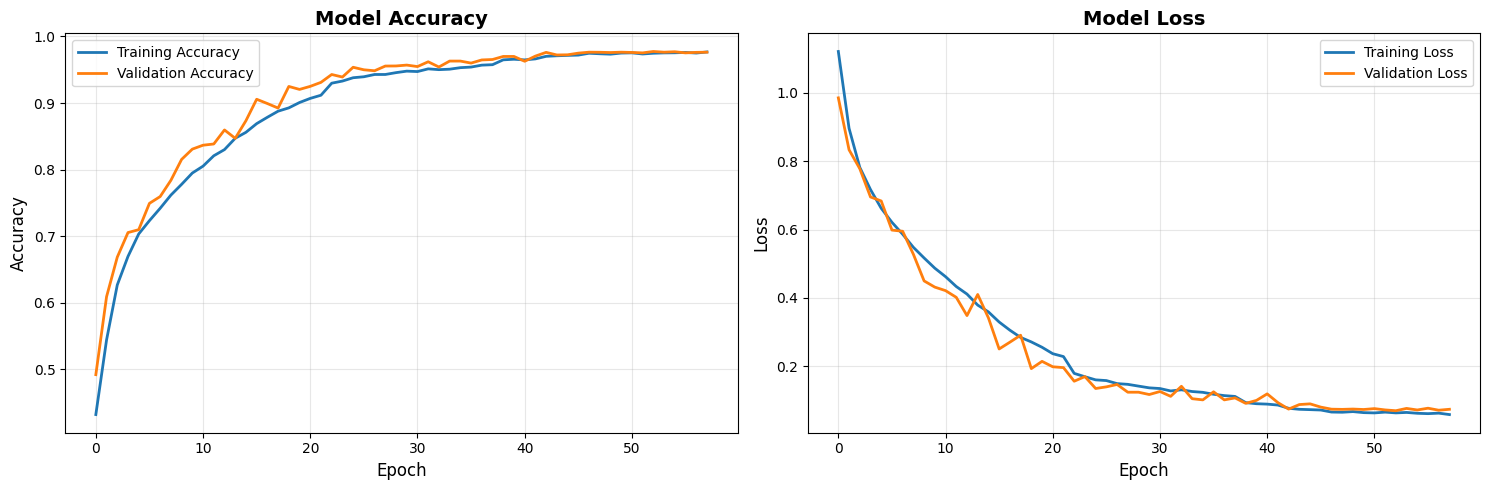

In [18]:
# ==============================================================================
# CELL 15: PLOT TRAINING HISTORY
# ==============================================================================

def plot_training_history(history):
    """Plots training/validation accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step

PER-CLASS PERFORMANCE
               precision    recall  f1-score   support

        Cargo     0.9834    0.9777    0.9806      6199
Passengership     0.9697    0.9836    0.9766      3056
       Tanker     0.9797    0.9690    0.9743      4426
          Tug     0.9685    0.9930    0.9806      1581

     accuracy                         0.9780     15262
    macro avg     0.9753    0.9809    0.9780     15262
 weighted avg     0.9781    0.9780    0.9780     15262



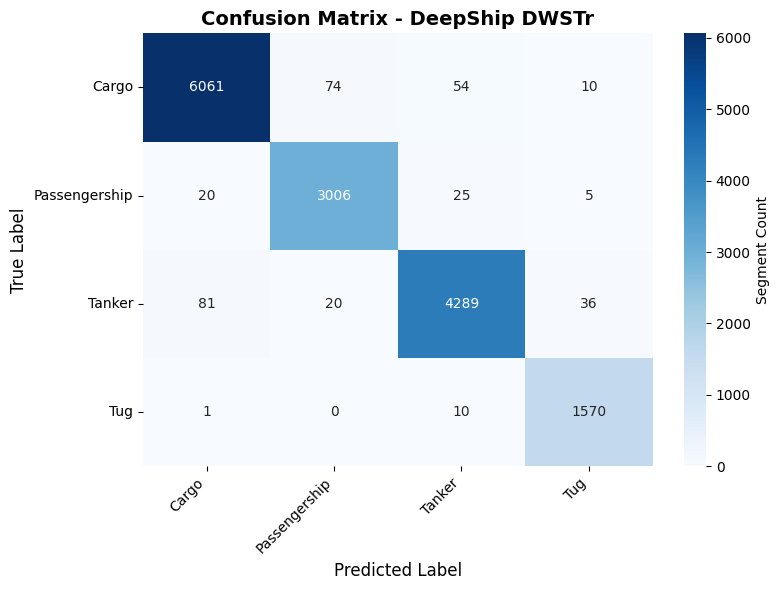


Per-Class Accuracy Breakdown:
  Cargo          : 97.77%
  Passengership  : 98.36%
  Tanker         : 96.90%
  Tug            : 99.30%


In [19]:
# ==============================================================================
# CELL 16: CONFUSION MATRIX & PER-CLASS PERFORMANCE
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predictions for the test set
y_pred = best_model.predict(X_test, batch_size=BATCH_SIZE)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print classification report
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=class_names,
    digits=4
))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={'label': 'Segment Count'}
)
plt.title('Confusion Matrix - DeepShip DWSTr', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display explicit per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy Breakdown:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name:15s}: {per_class_accuracy[i]*100:.2f}%")